(cell_cycle)=

# Score cell-cycle activity

Single-cell RNA sequencing captures a snapshot of expression. Genes associated with DNA
replication (S phase) and preparation for division (G2/M) can help identify cycling cells.
These programs may separate cells of the same type into different clusters, or reflect
proliferation that is central to the study.

CyteArc compares the expression of S and G2M marker genes with control genes of similar
average expression, then assigns a phase from the two scores. These are relative expression
scores, not measurements of division rate. In particular, a G1 assignment does not distinguish
cycling G1 cells from cells outside the cycle.

## Open the prepared analysis

We use the embryonic mouse pancreas data from [Bastidas-Ponce et al., 2019](https://journals.biologists.com/dev/article/146/12/dev173849/19483/).
The saved analysis provides the selected cells and UMAP for inspecting the scores.

In [1]:
# Import plotting, array, and table tools.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Import CyteArc to open the prepared store and score its cells.
import cytearc

# Keep warnings visible while hiding routine progress messages.
cytearc.configure_output(level="WARNING", progress=False)

# Download the prepared pancreas store and its saved analysis.
dataset = cytearc.cytebase.connect("cytearc_docs").download_dataset(
    name="bastidas-ponce_4K_pancreas-d15_rnaseq",
    destination="cytearc_datasets",
    zarr=True,
)

# Open the store so scoring can save its results.
ds = cytearc.DataStore(f"{dataset}/data.zarr", nthreads=4)

# Reuse the saved analysis and its selected cells.
analysis_run = ds.pipeline.open(label="docs_default")

# Inspect the opened assays and their dimensions.
ds

DataStore has 3696 (3696) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'G2M_score', 'RNA_UMAP1', 
            'RNA_UMAP2', 'RNA_clusters', 'RNA_leiden_cluster', 'RNA_nCounts', 'RNA_nFeatures', 
            'RNA_percentMito', 'RNA_percentRibo', 'S_score', 'clusters', 'clusters_coarse'
   RNA assay has 27998 features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'highly_variable_genes', 
            'nCells'

Started: 2026-10-08T11:02:51.607094Z | Wall time: 21.270 s

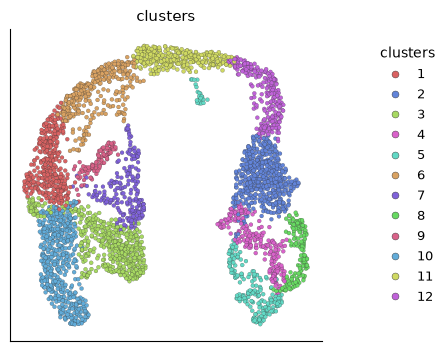

Started: 2026-10-08T11:03:12.882312Z | Wall time: 0.905 s

In [2]:
# Locate the saved pancreas clusters before scoring.
ds.plots.embedding(run=analysis_run, color_by="clusters")

## Run cell-cycle scoring

For each phase, CyteArc:

- Matches S and G2M markers to the assay's gene names, using its bundled lists by default.
- Groups genes by their mean log-normalized expression across the selected cells.
- Samples control genes from the expression bins containing that phase's markers.
- Subtracts the mean control expression from the mean marker expression in each cell.

Cells with both scores below zero are assigned G1. Otherwise, G2M is assigned when its
score exceeds the S score; the remaining cells, including ties, are assigned S.

In [3]:
# Score S and G2M programs in the saved analysis cells.
cell_cycle_ref = ds.scores.cell_cycle(analysis_run["analysis_cell_selection"])

# Open the saved scores and phase assignments.
cell_cycle_values = ds.artifacts.load(cell_cycle_ref)

# Read each selected cell's S-phase score.
s_score = np.asarray(cell_cycle_values["s_score"][:])

# Read each selected cell's G2M-phase score.
g2m_score = np.asarray(cell_cycle_values["g2m_score"][:])

# Read phase labels in the same cell order as the scores.
phase = np.asarray(cell_cycle_values["phase"][:]).astype(str)

# Preview the two scores alongside each cell's assigned phase.
pd.DataFrame({"S score": s_score, "G2M score": g2m_score, "phase": phase}).head()

,S score,G2M score,phase
0,-0.024501,-0.040976,G1
1,0.020201,-0.035924,S
2,-0.001931,-0.044457,G1
3,0.104609,0.018123,S
4,-0.006316,-0.035153,G1


Started: 2026-10-08T11:03:13.792188Z | Wall time: 3.253 s

The saved output warns that two bundled G2M markers are absent from this assay. Scoring
uses the remaining matches. Check marker coverage when applying the scorer to another dataset.

## Visualize cell-cycle phases

Pass the result to the UMAP plot to color cells by their assigned phase.

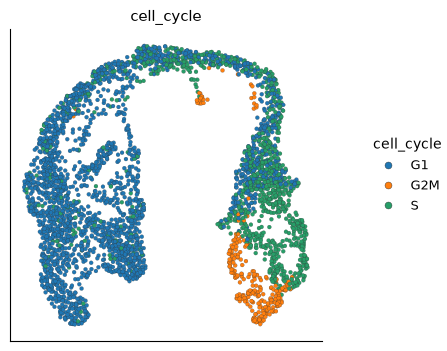

Started: 2026-10-08T11:03:17.049644Z | Wall time: 0.503 s

In [4]:
# Color the saved UMAP by each cell's assigned phase.
ds.plots.embedding(layout=analysis_run["umap"], color_by=cell_cycle_ref)

Look for populations enriched for S or G2M. The table below reports phase fractions within
each cluster, so rows sum to one. It shows where the expression programs are concentrated;
it does not measure how quickly those populations divide.

In [5]:
# Compare phase fractions within each saved cluster.
pd.crosstab(analysis_run.cells.fetch("clusters"), phase, normalize="index")

col_0,G1,G2M,S
row_0,,,
1,0.912698,0.000000,0.087302
2,0.413919,0.016484,0.569597
3,0.933063,0.000000,0.066937
4,0.069767,0.065116,0.865116
5,0.000000,0.955157,0.044843
6,0.823529,0.005882,0.170588
7,0.926829,0.000000,0.073171
8,0.000000,0.110345,0.889655
9,0.956989,0.000000,0.043011


Started: 2026-10-08T11:03:17.556019Z | Wall time: 0.054 s

Plot both continuous scores as well as the assigned phase. Cells near a phase boundary
can have similar scores even when the categorical labels differ.

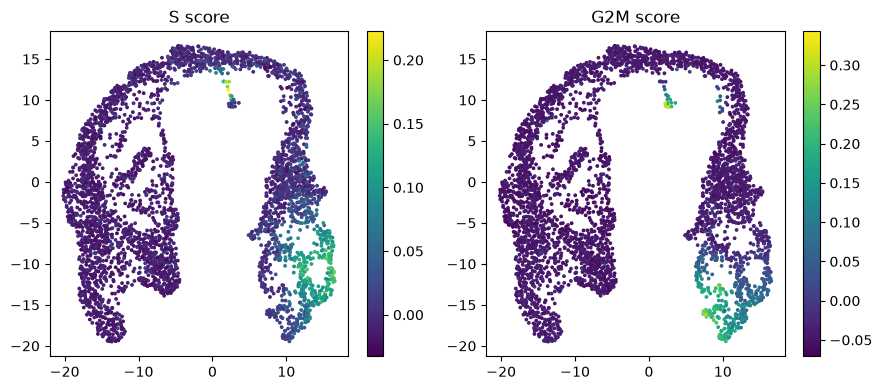

Started: 2026-10-08T11:03:17.612506Z | Wall time: 0.676 s

In [6]:
# Read UMAP coordinates in the same cell order as the scores.
umap = analysis_run.cells.to_pandas_dataframe(["umap_1", "umap_2"])

# Create one panel for each cell-cycle score.
figure, axes = plt.subplots(1, 2, figsize=(9, 4))

# Plot S and G2M scores on their respective panels.
for axis, values, title in (
    (axes[0], s_score, "S score"),
    (axes[1], g2m_score, "G2M score"),
):

    # Color each cell by this panel's phase score.
    points = axis.scatter(umap["umap_1"], umap["umap_2"], c=values, s=3)

    # Identify the phase score shown in the panel.
    axis.set_title(title)

    # Show the score scale used to color the cells.
    figure.colorbar(points, ax=axis)

# Make room for panel titles and color scales.
figure.tight_layout()

# Display the completed score comparison.
figure

## Common mistakes and limitations

- Scoring against names the bundled lists cannot match: matching is case-insensitive on human and mouse gene symbols, so Ensembl IDs need a corresponding marker list or a gene-symbol mapping. Missing markers warn and scoring continues on the remaining matches; a phase with
no matches raises an error, and a small matched set may not represent the whole program.
- Comparing scores across runs or datasets: control genes are sampled from the selected cells' expression bins, so scores are comparable only within one scoring result, and low counts can weaken the measured signal.
- Reading the phase labels as observations: the assignment is a rule over two relative scores, so inspect several phase markers and the continuous scores near phase boundaries before interpreting proliferation.